In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from matplotlib.pyplot import cm

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
pilot_analysis = False
unique_subject_ids = [5, 10, 11, 14]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
unique_sessions = [2, 3, 4]
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [4]:
if not recent_results:
    raise Exception('No files found')
print(recent_results)

['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behavioural_output_sub-011_session-03_skyra_2025-04-11_11-31-46.csv',

### Remove invalid files

In [5]:
# Remove files that contain invalid data
raw_output_path = '/Volumes/project/3025011.02/raw/'
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behaviour

In [6]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if pilot_analysis:
    combined_results_dataframe.rename(columns={'iti': 'trial_duration'}, inplace=True)
    combined_results_dataframe['stimuli_type'] = combined_results_dataframe['stimuli_type'].replace(3, 2)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.741947e+09     down                Even   
1         1        1.741947e+09       up                Even   
2         2        1.741947e+09       up                Even   
3         3        1.741947e+09     down                Even   
4         4        1.741947e+09     down                Even   
...     ...                 ...      ...                 ...   
8011    663        1.744386e+09       up                True   
8012    664        1.744386e+09       up                True   
8013    665        1.744386e+09     down               False   
8014    666        1.744386e+09     down                True   
8015    667        1.744386e+09     down               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   False   1.741947e+09  0.692   1.741947e+09             1   
1                    True   1.741947e+09  0.940   1.741947e+09         

# Flip results if joystick orientation was incorrect
Specifically, switch the response and probability

In [7]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_results_dataframe['sub_session'] = combined_results_dataframe['subject_id'] + '_' + combined_results_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_results_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_results_dataframe.loc[mask, 'probability_condition'] = (
    combined_results_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_results_dataframe.loc[mask, 'response'] = (
    combined_results_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_results_dataframe.drop(columns='sub_session', inplace=True)

print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.741947e+09     down                Even   
1         1        1.741947e+09       up                Even   
2         2        1.741947e+09       up                Even   
3         3        1.741947e+09     down                Even   
4         4        1.741947e+09     down                Even   
...     ...                 ...      ...                 ...   
8011    663        1.744386e+09       up                True   
8012    664        1.744386e+09       up                True   
8013    665        1.744386e+09     down               False   
8014    666        1.744386e+09     down                True   
8015    667        1.744386e+09     down               False   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   False   1.741947e+09  0.692   1.741947e+09             1   
1                    True   1.741947e+09  0.940   1.741947e+09         

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [8]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [9]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition congruency
0                1                     50  undefined
1                1                     50  undefined
2                1                     50  undefined
3                2                     50  undefined
4                2                     50  undefined
...            ...                    ...        ...
8011             1                     80  congruent
8012             1                     80  congruent
8013             1                     80  congruent
8014             2                     20  congruent
8015             1                     80  congruent

[8016 rows x 3 columns]


In [10]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

      stimuli_type valence
0                1   angry
1                1   angry
2                1   angry
3                2   happy
4                2   happy
...            ...     ...
8011             1   angry
8012             1   angry
8013             1   angry
8014             2   happy
8015             1   angry

[8016 rows x 2 columns]


In [11]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

# Objectively correct answer binned after every switch
Sorted for valence

In [12]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'valence', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'valence'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch valence
8       sub-005      8             1                     20  False   angry
11      sub-005     11             1                     20  False   angry
12      sub-005     12             1                     20  False   angry
14      sub-005     14             1                     20  False   angry
15      sub-005     15             1                     20  False   angry
...         ...    ...           ...                    ...    ...     ...
8007    sub-014    659             2                     20  False   happy
8008    sub-014    660             2                     20  False   happy
8009    sub-014    661             2                     20  False   happy
8010    sub-014    662             2                     20  False   happy
8014    sub-014    666             2                     20  False   happy

[7920 rows x 6 columns]
0   subject_id stimuli_type valence  0  1  2  3  4  5
1      sub-005       

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

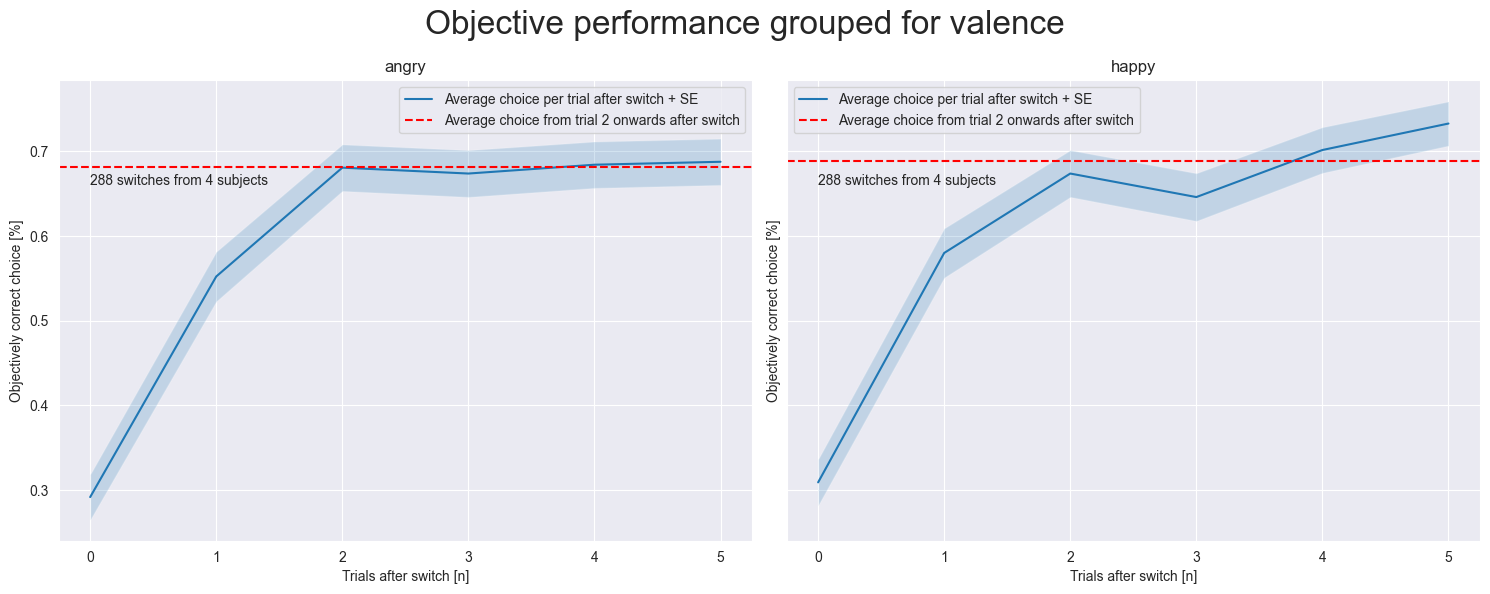

In [13]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['valence'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['valence']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['valence']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

congruency_list = df['valence'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.66, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence.pdf'))
plt.show()

# Now the same but split for congruency

In [14]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
8       sub-005      8             1                     20  False   
11      sub-005     11             1                     20  False   
12      sub-005     12             1                     20  False   
14      sub-005     14             1                     20  False   
15      sub-005     15             1                     20  False   
...         ...    ...           ...                    ...    ...   
8007    sub-014    659             2                     20  False   
8008    sub-014    660             2                     20  False   
8009    sub-014    661             2                     20  False   
8010    sub-014    662             2                     20  False   
8014    sub-014    666             2                     20  False   

       congruency  
8     incongruent  
11    incongruent  
12    incongruent  
14    incongruent  
15    incongruent  
...           ...  
8007    congruent  

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

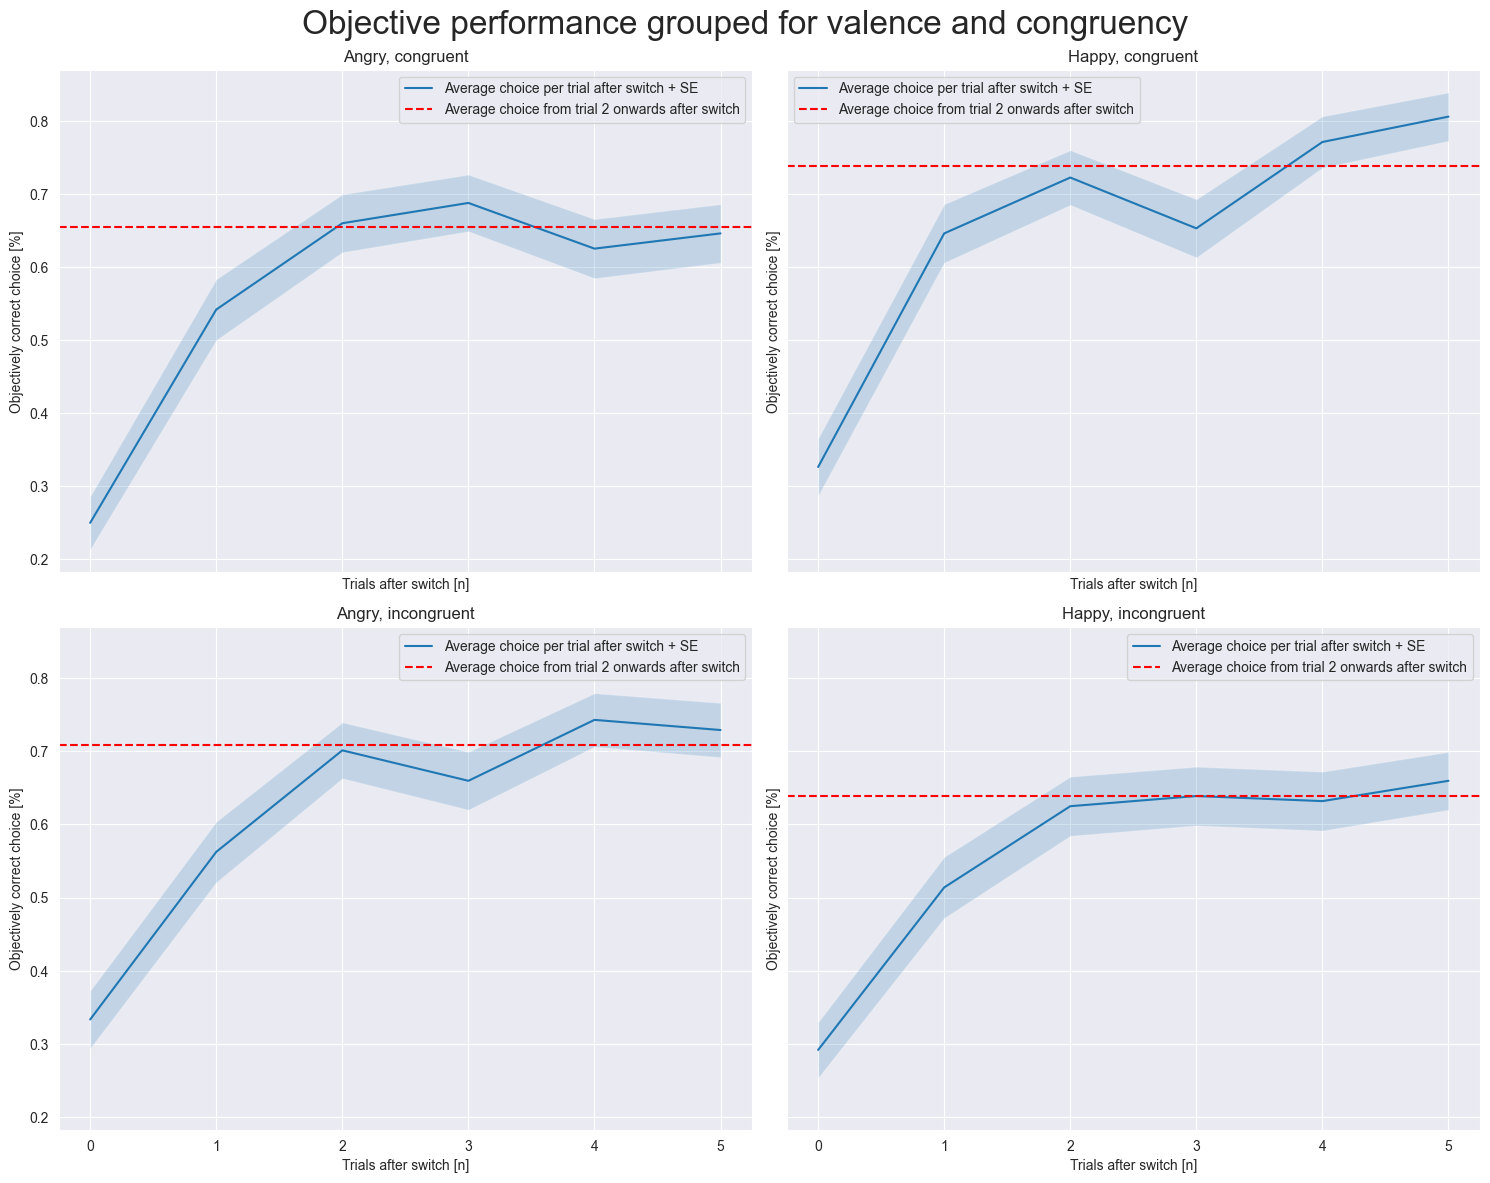

In [15]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [16]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch response
8       sub-005      8             1                     20  False       up
11      sub-005     11             1                     20  False       up
12      sub-005     12             1                     20  False       up
14      sub-005     14             1                     20  False     down
15      sub-005     15             1                     20  False     down
...         ...    ...           ...                    ...    ...      ...
8007    sub-014    659             2                     20  False     down
8008    sub-014    660             2                     20  False     down
8009    sub-014    661             2                     20  False     down
8010    sub-014    662             2                     20  False     down
8014    sub-014    666             2                     20  False     down

[7920 rows x 6 columns]
0   subject_id stimuli_type response  0  1  2  3  4  5
1      s

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

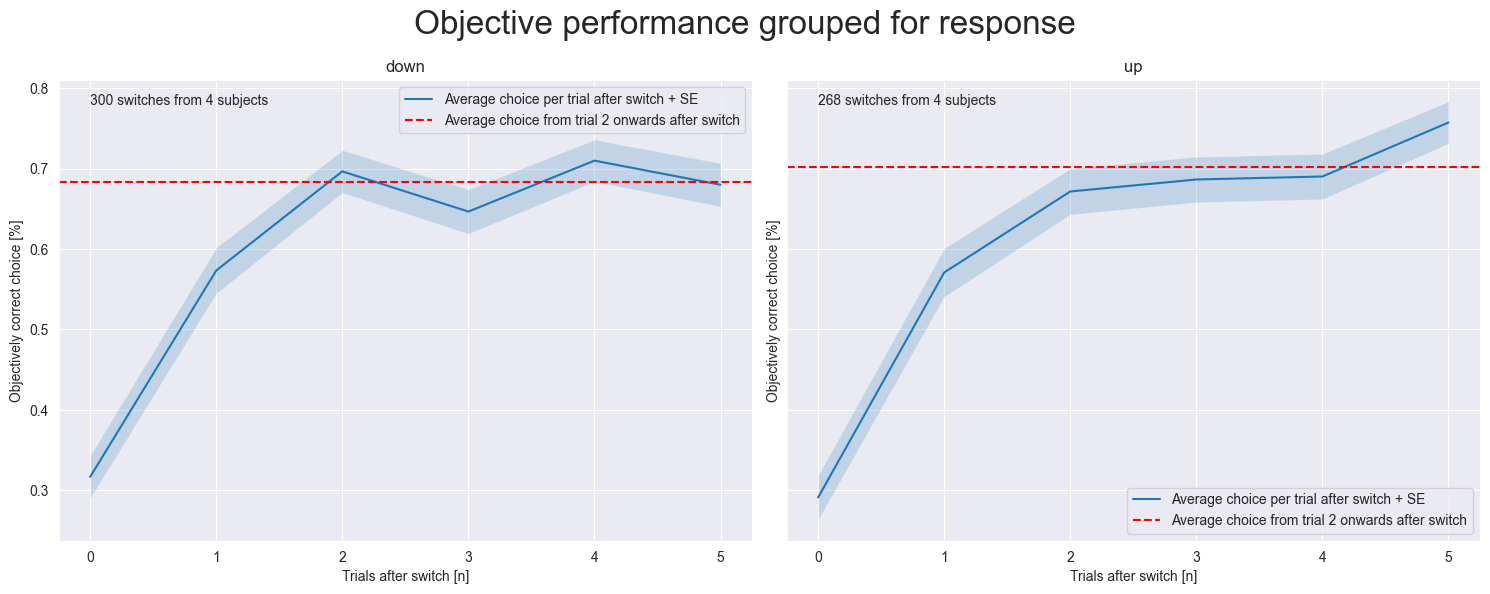

In [17]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [18]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
8       sub-005      8             1                     20  False   
11      sub-005     11             1                     20  False   
12      sub-005     12             1                     20  False   
14      sub-005     14             1                     20  False   
15      sub-005     15             1                     20  False   
...         ...    ...           ...                    ...    ...   
8007    sub-014    659             2                     20  False   
8008    sub-014    660             2                     20  False   
8009    sub-014    661             2                     20  False   
8010    sub-014    662             2                     20  False   
8014    sub-014    666             2                     20  False   

       congruency response  
8     incongruent       up  
11    incongruent       up  
12    incongruent       up  
14    incongruent     down  
15    incongru

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

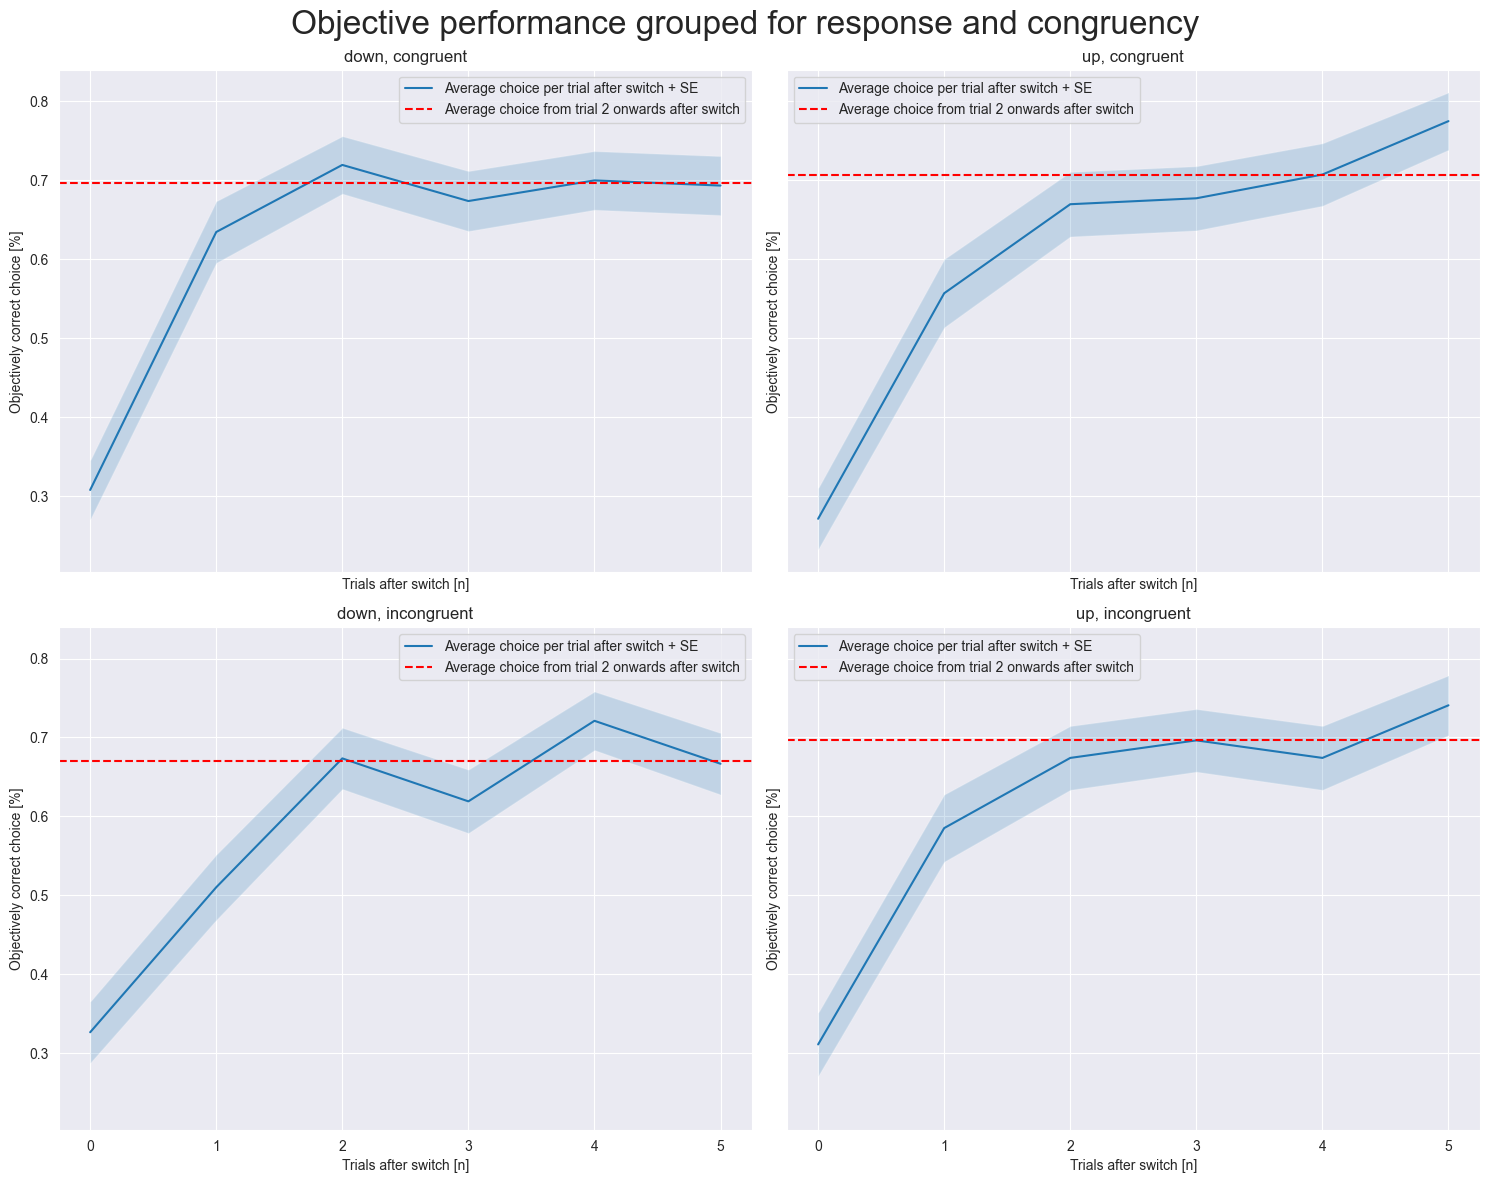

In [19]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
        axs[i].set_xlabel('Trials after switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [20]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch response
8       sub-005      8             1                     20  False       up
11      sub-005     11             1                     20  False       up
12      sub-005     12             1                     20  False       up
14      sub-005     14             1                     20  False     down
15      sub-005     15             1                     20  False     down
...         ...    ...           ...                    ...    ...      ...
8007    sub-014    659             2                     20  False     down
8008    sub-014    660             2                     20  False     down
8009    sub-014    661             2                     20  False     down
8010    sub-014    662             2                     20  False     down
8014    sub-014    666             2                     20  False     down

[7920 rows x 6 columns]
0   subject_id stimuli_type response  -5  -4  -3  -2  -1  0  1 

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

# Subplots for incongruent and congruent switches

In [21]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_switches_dataframe)

     subject_id  trial  stimuli_type  probability_condition switch  \
8       sub-005      8             1                     20  False   
11      sub-005     11             1                     20  False   
12      sub-005     12             1                     20  False   
14      sub-005     14             1                     20  False   
15      sub-005     15             1                     20  False   
...         ...    ...           ...                    ...    ...   
8007    sub-014    659             2                     20  False   
8008    sub-014    660             2                     20  False   
8009    sub-014    661             2                     20  False   
8010    sub-014    662             2                     20  False   
8014    sub-014    666             2                     20  False   

       congruency     session  
8     incongruent  session-02  
11    incongruent  session-02  
12    incongruent  session-02  
14    incongruent  session-02  

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

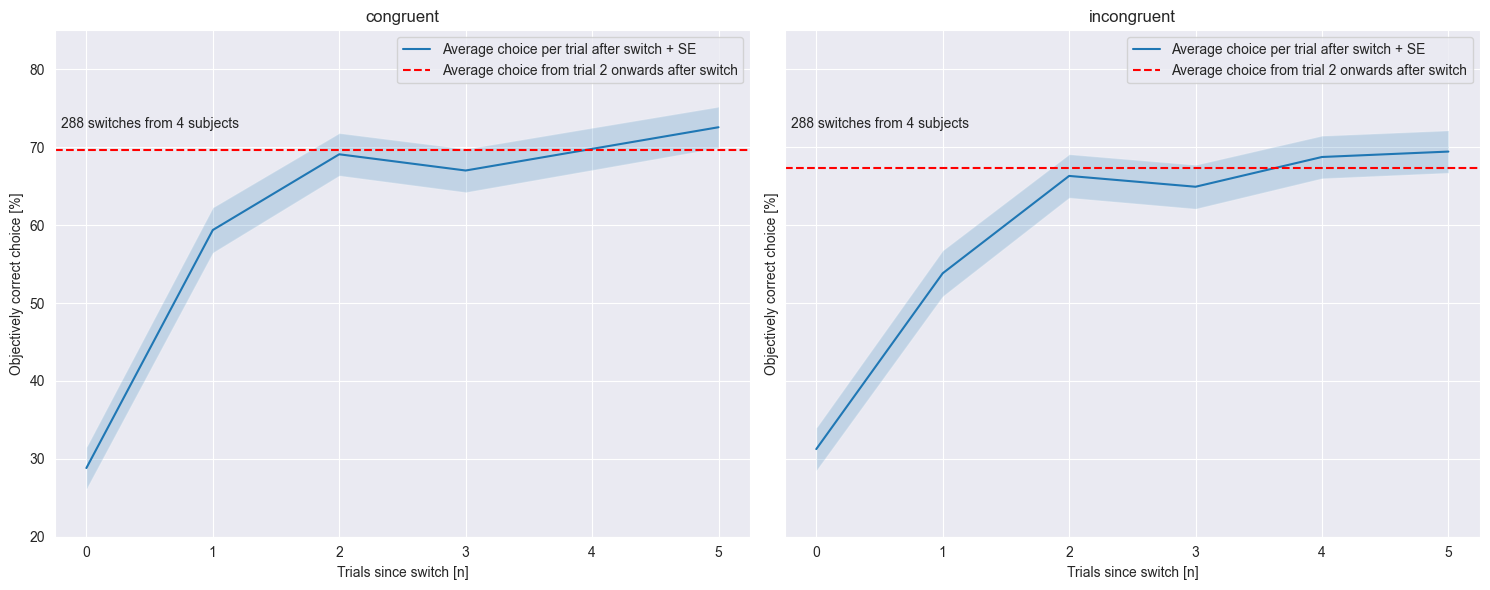

In [22]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

## Comparing congruency direction

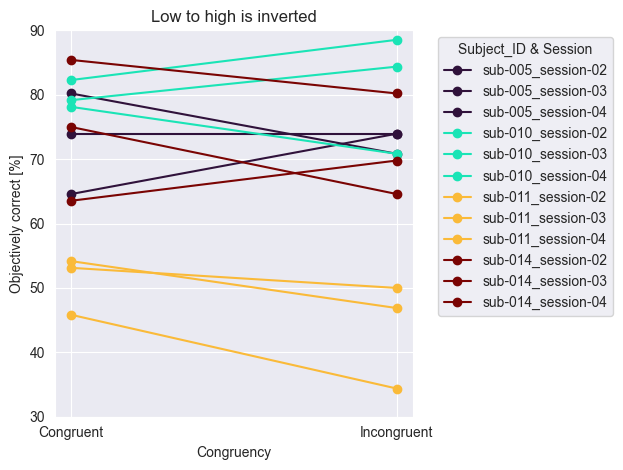

In [23]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')
df['subject_id_session'] = df['subject_id'] + '_' + df['session']

unique_subjects = df['subject_id_session'].unique()
subject_counts = len(unique_subjects)

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency','subject_id_session']).mean()
means_overall = means*100
means_overall = means_overall.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1)

df = average_choice_after_switch_total.reset_index()

# Create a mapping for congruency values to x-axis positions:
# 1 for 'congruent' and 2 for 'incongruent'
x_mapping = {'congruent': 1, 'incongruent': 2}
df['x'] = df['congruency'].map(x_mapping)

colour = iter(cm.turbo(np.linspace(0, 1, len(unique_subject_ids))))
prev_subject = None

# Loop through each subject and plot their corresponding data points
for subject in df['subject_id_session'].unique():
    subject_data = df[df['subject_id_session'] == subject].sort_values(by='x')
    subject_data['value'] = subject_data.iloc[:,2]
    value_congruent = subject_data.loc[subject_data['congruency'] == 'congruent', 'value'].iloc[0]
    value_incongruent = subject_data.loc[subject_data['congruency'] == 'incongruent', 'value'].iloc[0]

    # If the subject changes, increment the counter
    current_subject = subject.split('_')[0]
    if current_subject != prev_subject:
        line_colour = next(colour)
        prev_subject = current_subject

    # Choose colour based on comparison: green if incongruent is lower, red if higher
    if value_incongruent < value_congruent:
        line_color = 'green'
    elif value_incongruent > value_congruent:
        line_color = 'red'
    else:
        line_color = 'blue'  # Fallback colour if both values are equal

    plt.plot(subject_data['x'], subject_data.iloc[:, 2], marker='o', label=subject, color=line_colour)

# Set x-axis ticks and labels
plt.xticks([1, 2], ['Congruent', 'Incongruent'])
plt.xlabel('Congruency')
plt.ylabel('Objectively correct [%]')  # Replace 'Value' with your actual y-axis label if needed
plt.title('Low to high is inverted')
plt.ylim(30, 90)

# Optional: display a legend if the number of subjects is not too high
plt.legend(title='Subject_ID & Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_comparing_congruency.pdf'))
plt.show()

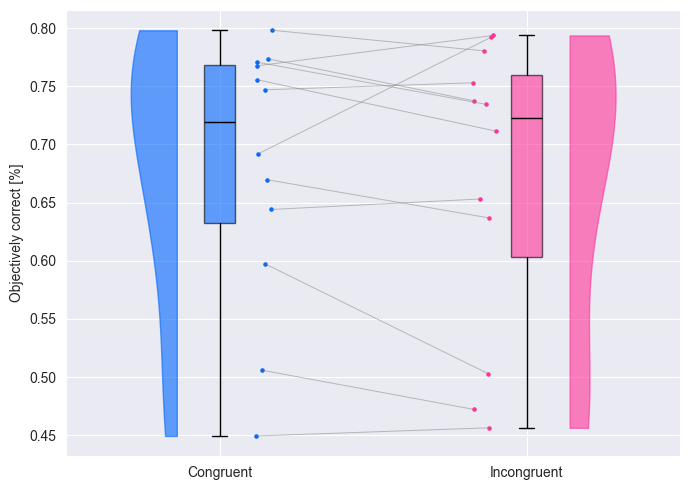

In [24]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_congruency'
)

In [25]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = [-6, 6]
static_mapping = {
    0: 'subject_id',
    1: 'stimuli_type',
    2: 'congruency',
}

# pick the first and last values you want in the numeric run
start_value = plot_range[0]
end_value   = plot_range[1]

# build the list of values
values = list(range(start_value, end_value + 1))

# compute where the keys should start (one past your highest static key)
start_key = max(static_mapping) + 1

# zip them together into a dict
numeric_mapping = dict(zip(range(start_key, start_key + len(values)), values))

# merge
mapping = {**static_mapping, **numeric_mapping}

print(mapping)

group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_switches_dataframe)

{0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: -6, 4: -5, 5: -4, 6: -3, 7: -2, 8: -1, 9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6}
     subject_id  trial  stimuli_type  probability_condition switch  \
8       sub-005      8             1                     20  False   
11      sub-005     11             1                     20  False   
12      sub-005     12             1                     20  False   
14      sub-005     14             1                     20  False   
15      sub-005     15             1                     20  False   
...         ...    ...           ...                    ...    ...   
8007    sub-014    659             2                     20  False   
8008    sub-014    660             2                     20  False   
8009    sub-014    661             2                     20  False   
8010    sub-014    662             2                     20  False   
8014    sub-014    666             2                     20  False   

       congruen

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

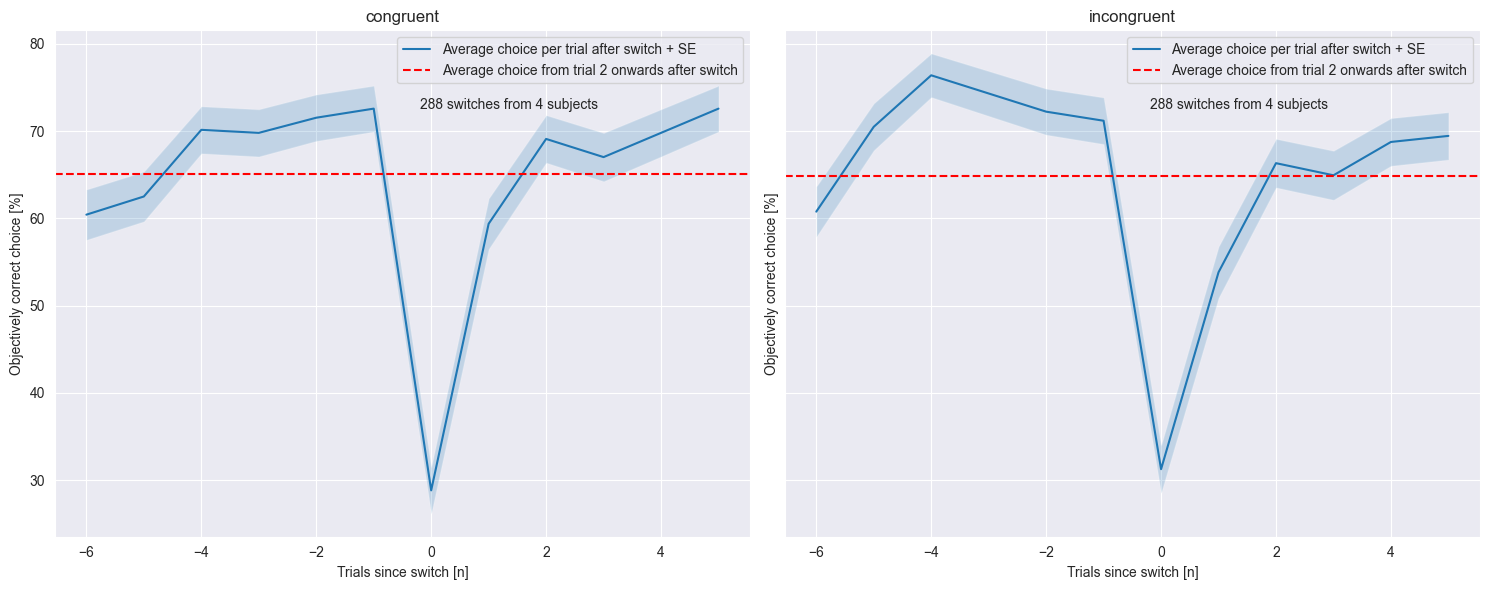

In [26]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since switch [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

#plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency_before_and_after.pdf'))
plt.show()
plot_range = [0, 6]

# Overall objective performance over time
This will be used to check whether their performance stabilises after the 1st session

In [27]:
'''
if 'session-04' in unique_sessions:
    dataframe_1 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-01']
    dataframe_1 = dataframe_1.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()

    dataframe_2 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-02']
    dataframe_2 = dataframe_2.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()

    dataframe_3 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-03']
    dataframe_3 = dataframe_3.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_3 = dataframe_3['objectively_correct_boolean'].dropna().tolist()

    dataframe_4 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-04']
    dataframe_4 = dataframe_4.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()
    list_4 = dataframe_4['objectively_correct_boolean'].dropna().tolist()

    valence_list = [list_1, list_2, list_3, list_4]

    # Create empty plot
    fig, ax = plt.subplots(figsize=(10, 7))

    # Create a list of colors
    plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
    c = 'black'

    # Boxplot data
    bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                    capprops=dict(color=c),
                    whiskerprops=dict(color=c),
                    flierprops=dict(color=c, markeredgecolor=c),
                    medianprops=dict(color=c))
    # Change to the desired color and add transparency
    for patch, color in zip(bp['boxes'], plot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for median in bp['medians']:
        median.set_color('black')
    # Violinplot data (specify points as length data)
    vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.5,
                       showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
    # Change to the desired color
    for idx, b in enumerate(vp['bodies']): # Slices it in half
        # Change to the desired color
        b.set_color(plot_colors[idx])

    # Scatterplot data
    for idx, features in enumerate(valence_list):
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + .75)
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
        x = out + 0.4
        plt.scatter(x, features, s=5, c=plot_colors[idx])

    # Allocate labels to x- and y-axis
    plt.xticks(np.arange(1,5,1), ['Session 1','Session 2','Session 3','Session 4'])  # Set text labels.
    plt.ylabel('Objective performance [%]')
    plot_name = 'Objective performance over sessions'

    # Save and show plot
    plt.tight_layout()
    plt.title(plot_name)
    plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
    plt.show()
'''

"\nif 'session-04' in unique_sessions:\n    dataframe_1 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-01']\n    dataframe_1 = dataframe_1.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()\n    list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()\n\n    dataframe_2 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-02']\n    dataframe_2 = dataframe_2.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()\n    list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()\n\n    dataframe_3 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-03']\n    dataframe_3 = dataframe_3.groupby(['subject_id'])['objectively_correct_boolean'].mean().reset_index()\n    list_3 = dataframe_3['objectively_correct_boolean'].dropna().tolist()\n\n    dataframe_4 = combined_results_dataframe[combined_results_dataframe['session'] == 'session-04']\n    

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [28]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range, 'stimuli_type')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe[['trials_around_switch','stimuli_type','congruency']])

[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2315, 2325, 2331, 2339, 2349, 238

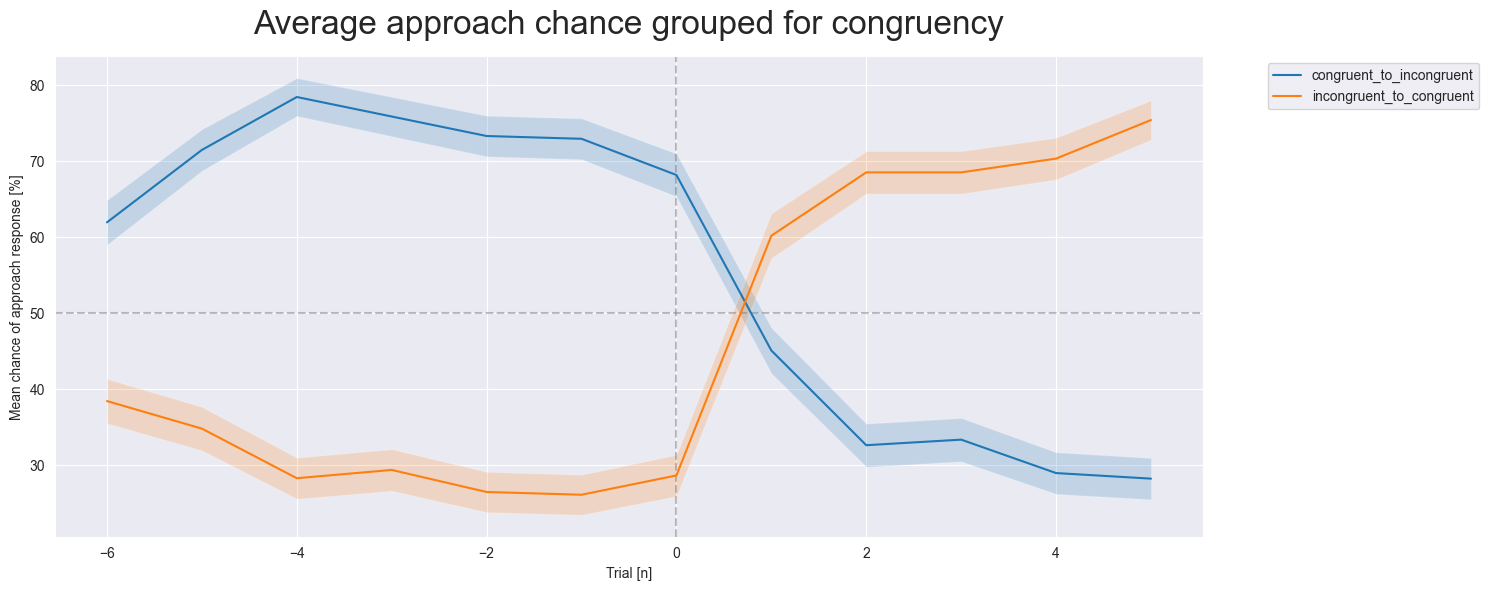

In [29]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for transition in transitions:
    subset = grouped_dataframe[grouped_dataframe['transitions_combined'] == transition]
    current_transition = subset['transitions_combined'].unique()
    if not subset.empty:
        plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
        plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for congruency', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_congruency.pdf'))
# Show the plot
plt.show()

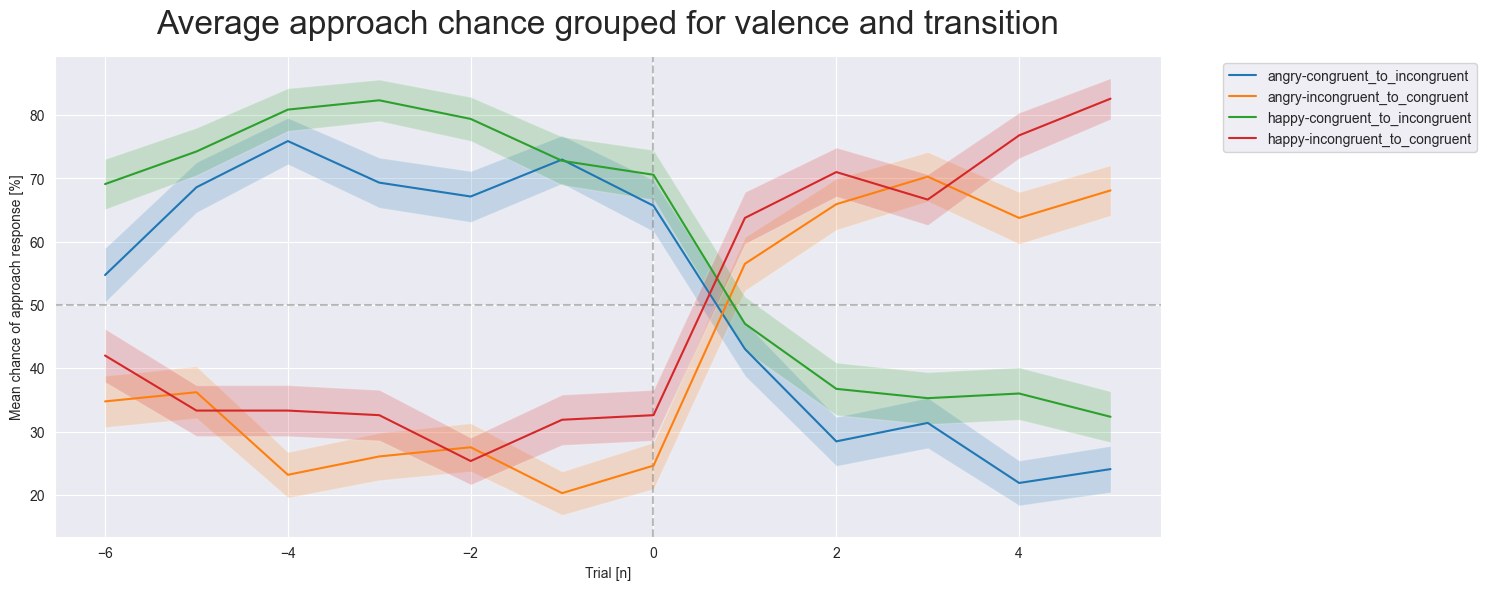

In [30]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

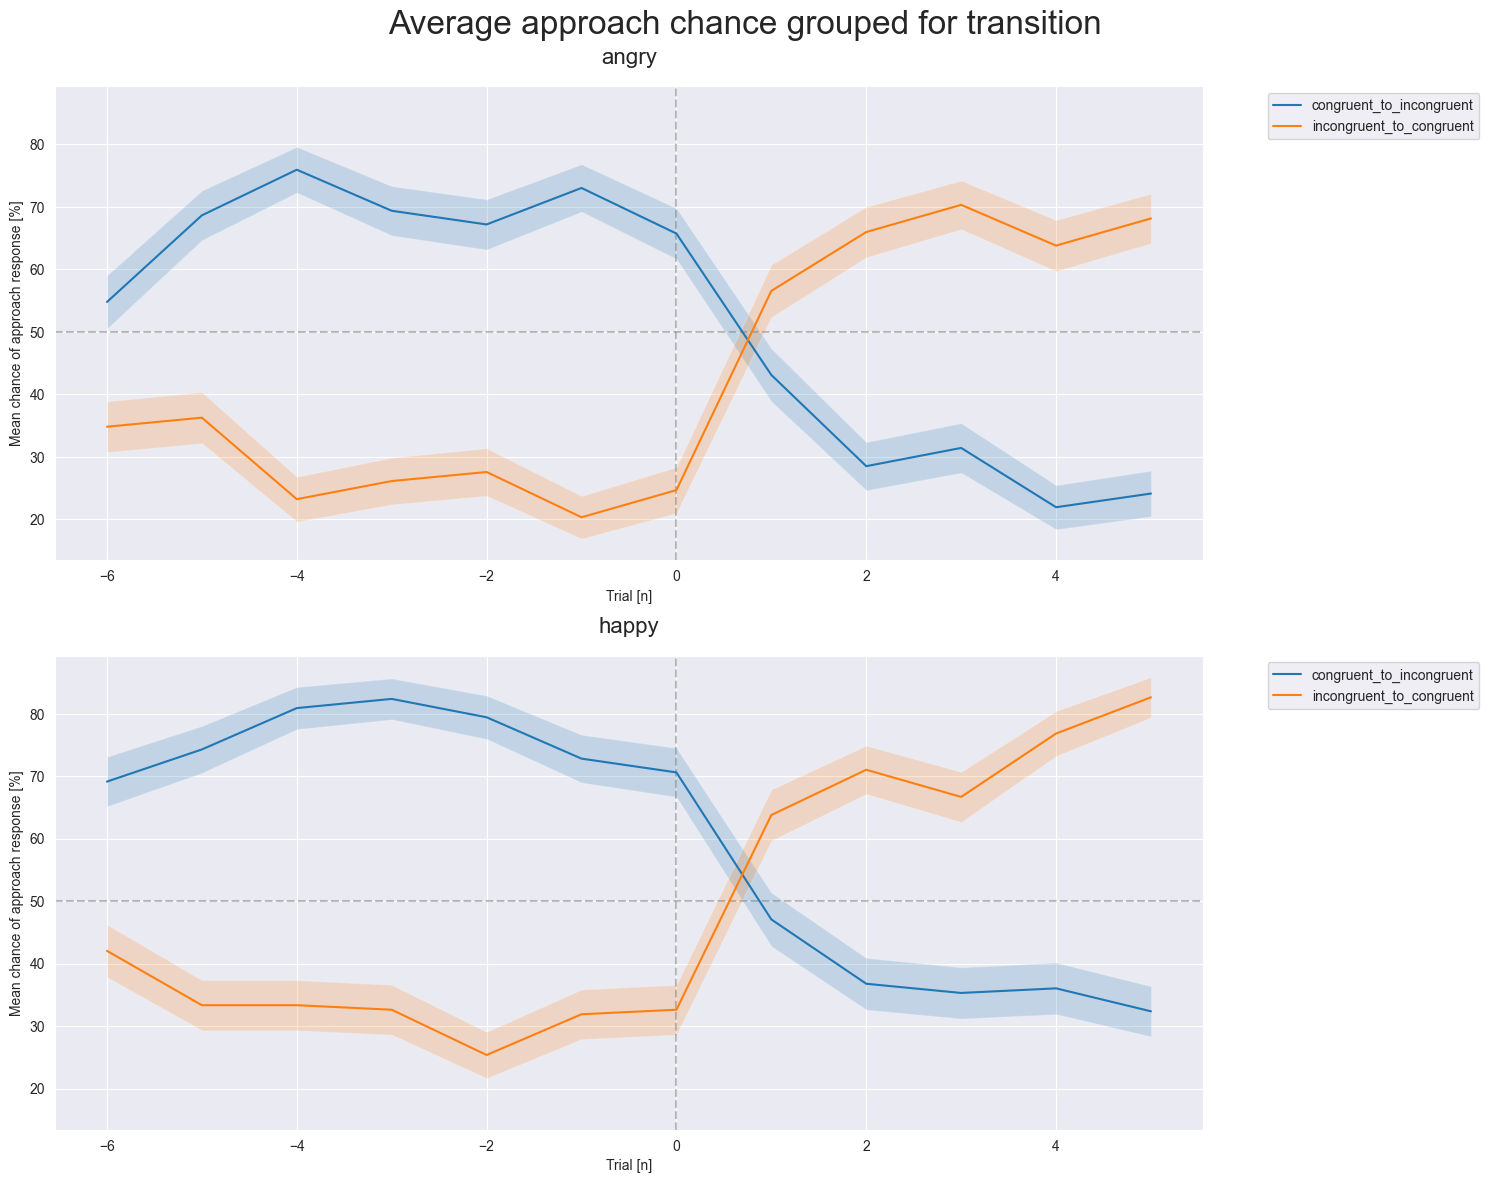

In [31]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

In [32]:
# Add a plot where the two emotions are combined and one transition is inverted to compare them bettter

# Plot volatile and stable blocks separately
Fix this, clearly broken

In [33]:
pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe[['subject_id', 'session', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:300: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


     subject_id     session  trial  stimuli_type  probability_condition  \
0       sub-005  session-02      8             1                     20   
3       sub-005  session-02     11             1                     20   
4       sub-005  session-02     12             1                     20   
6       sub-005  session-02     14             1                     20   
7       sub-005  session-02     15             1                     20   
10      sub-005  session-02     18             1                     20   
11      sub-005  session-02     19             1                     20   
15      sub-005  session-02     23             1                     20   
16      sub-005  session-02     24             1                     20   
18      sub-005  session-02     26             1                     20   
19      sub-005  session-02     27             1                     20   
24      sub-005  session-02     32             1                     20   
25      sub-005  session-

In [34]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
group_name = 'volatility'
session_name = 'session'
unique_group_types = dataframe[group_name].unique()
pd.set_option('display.max_rows', 20)
dataframe_with_session = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping, session_name)

print(dataframe_with_session)

dataframe_without_session = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

print(dataframe_without_session)

     subject_id  trial  stimuli_type  probability_condition switch volatility  \
0       sub-005      8             1                     20  False   volatile   
3       sub-005     11             1                     20  False   volatile   
4       sub-005     12             1                     20  False   volatile   
6       sub-005     14             1                     20  False   volatile   
7       sub-005     15             1                     20  False   volatile   
...         ...    ...           ...                    ...    ...        ...   
7911    sub-014    659             2                     20  False   volatile   
7912    sub-014    660             2                     20  False   volatile   
7913    sub-014    661             2                     20  False   volatile   
7914    sub-014    662             2                     20  False   volatile   
7918    sub-014    666             2                     20  False   volatile   

         session  
0     se

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

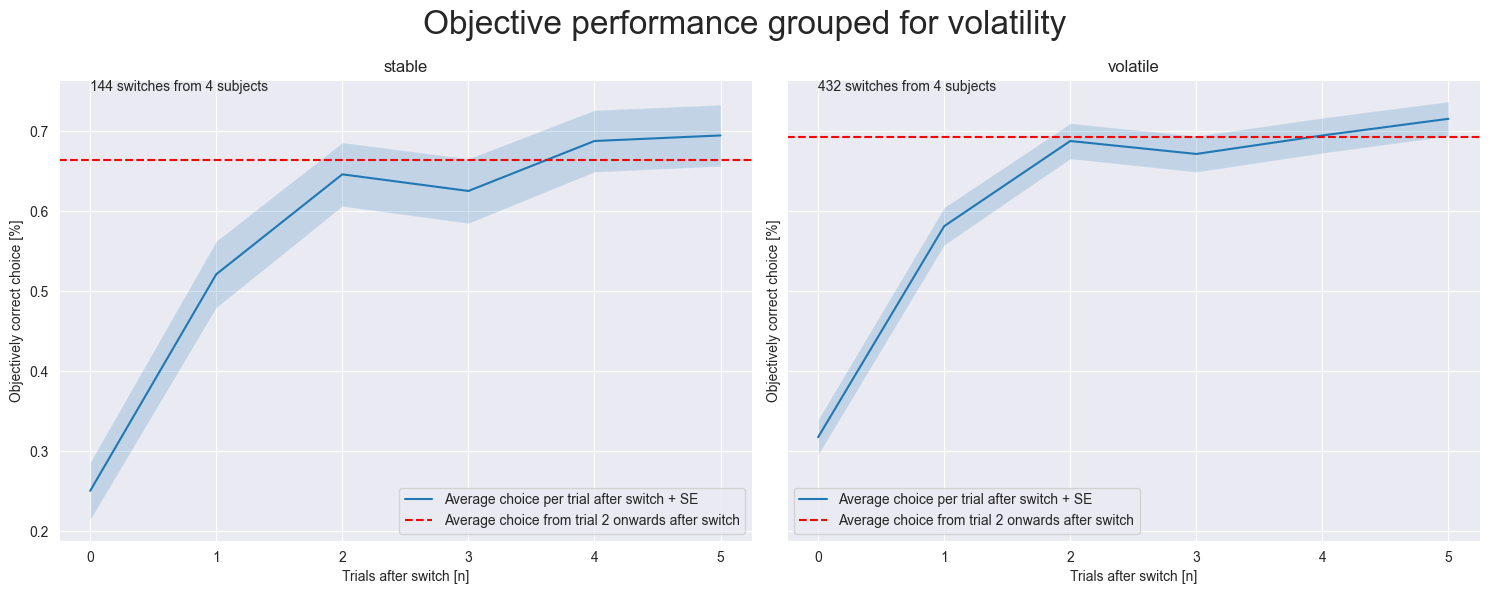

In [35]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_without_session.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe_without_session['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.75, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

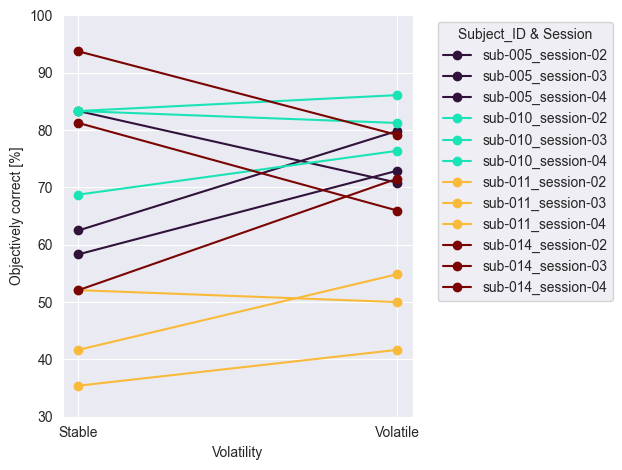

In [36]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_with_session.set_index('volatility')
df['subject_id_session'] = df['subject_id'] + '_' + df['session']

unique_subjects = df['subject_id_session'].unique()
subject_counts = len(unique_subjects)

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['volatility','subject_id_session']).mean()
means_overall = means*100
means_overall = means_overall.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1)

df = average_choice_after_switch_total.reset_index()

# Create a mapping for congruency values to x-axis positions:
# 1 for 'congruent' and 2 for 'incongruent'
x_mapping = {'stable': 1, 'volatile': 2}
df['x'] = df['volatility'].map(x_mapping)

colour = iter(cm.turbo(np.linspace(0, 1, len(unique_subject_ids))))
prev_subject = None

# Loop through each subject and plot their corresponding data points
for subject in df['subject_id_session'].unique():
    subject_data = df[df['subject_id_session'] == subject].sort_values(by='x')
    subject_data['value'] = subject_data.iloc[:,2]
    value_congruent = subject_data.loc[subject_data['volatility'] == 'stable', 'value'].iloc[0]
    value_incongruent = subject_data.loc[subject_data['volatility'] == 'volatile', 'value'].iloc[0]

    # If the subject changes, increment the counter
    current_subject = subject.split('_')[0]
    if current_subject != prev_subject:
        line_colour = next(colour)
        prev_subject = current_subject

    # Choose colour based on comparison: green if incongruent is lower, red if higher
    if value_incongruent < value_congruent:
        line_color = 'green'
    elif value_incongruent > value_congruent:
        line_color = 'red'
    else:
        line_color = 'blue'  # Fallback colour if both values are equal

    plt.plot(subject_data['x'], subject_data.iloc[:, 2], marker='o', label=subject, color=line_colour)

# Set x-axis ticks and labels
plt.xticks([1, 2], ['Stable', 'Volatile'])
plt.xlabel('Volatility')
plt.ylabel('Objectively correct [%]')  # Replace 'Value' with your actual y-axis label if needed
#plt.title('Low to high is inverted')
plt.ylim(30, 100)

# Optional: display a legend if the number of subjects is not too high
plt.legend(title='Subject_ID & Session', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_comparing_volatility.pdf'))
plt.show()

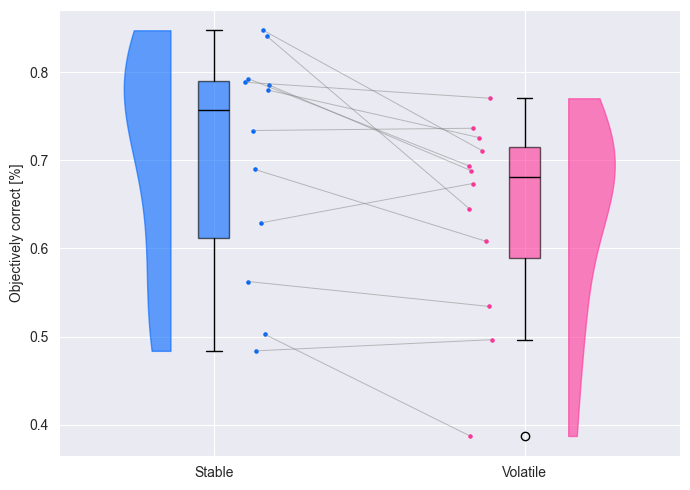

In [37]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = (
    dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Objectively correct [%]',
    plot_name='all_trials_objective_performance_volatility'
)

# Now do the same thing but split them for congruency & volatility

In [38]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe)

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:300: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


      trial  emotional_cue_time response objectively_correct  \
0         8        1.741947e+09       up               False   
3        11        1.741947e+09       up               False   
4        12        1.741947e+09       up               False   
6        14        1.741947e+09     down                True   
7        15        1.741947e+09     down                True   
...     ...                 ...      ...                 ...   
7911    659        1.744386e+09     down                True   
7912    660        1.744386e+09     down                True   
7913    661        1.744386e+09     down                True   
7914    662        1.744386e+09     down                True   
7918    666        1.744386e+09     down                True   

     subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   False   1.741947e+09  0.635   1.741947e+09             1   
3                   False   1.741947e+09  0.931   1.741947e+09         

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

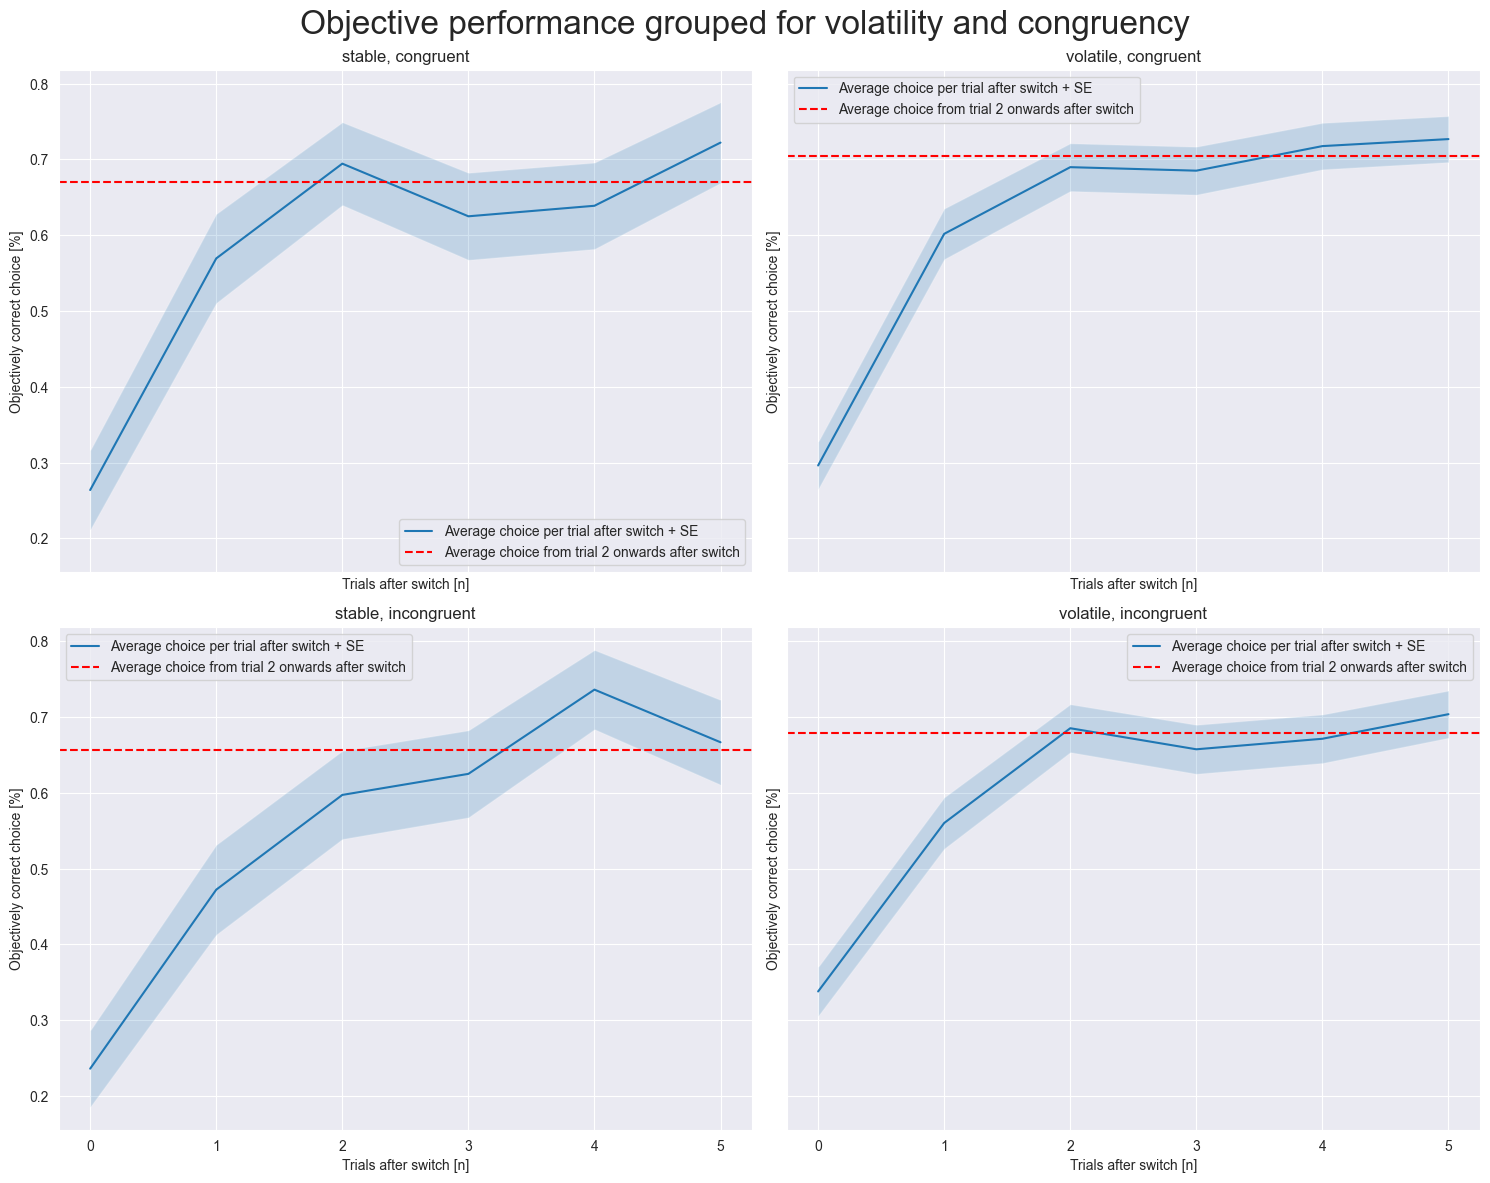

In [39]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

# Plot the full stable block

In [40]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:300: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


     subject_id  trial  stimuli_type  probability_condition switch volatility
0       sub-005      8             1                     20  False   volatile
3       sub-005     11             1                     20  False   volatile
4       sub-005     12             1                     20  False   volatile
6       sub-005     14             1                     20  False   volatile
7       sub-005     15             1                     20  False   volatile
...         ...    ...           ...                    ...    ...        ...
7911    sub-014    659             2                     20  False   volatile
7912    sub-014    660             2                     20  False   volatile
7913    sub-014    661             2                     20  False   volatile
7914    sub-014    662             2                     20  False   volatile
7918    sub-014    666             2                     20  False   volatile

[7920 rows x 6 columns]
0   subject_id stimuli_type volatility 

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:685: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  input_dataframe['switch'].iloc[0] = 'False'
/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_fun

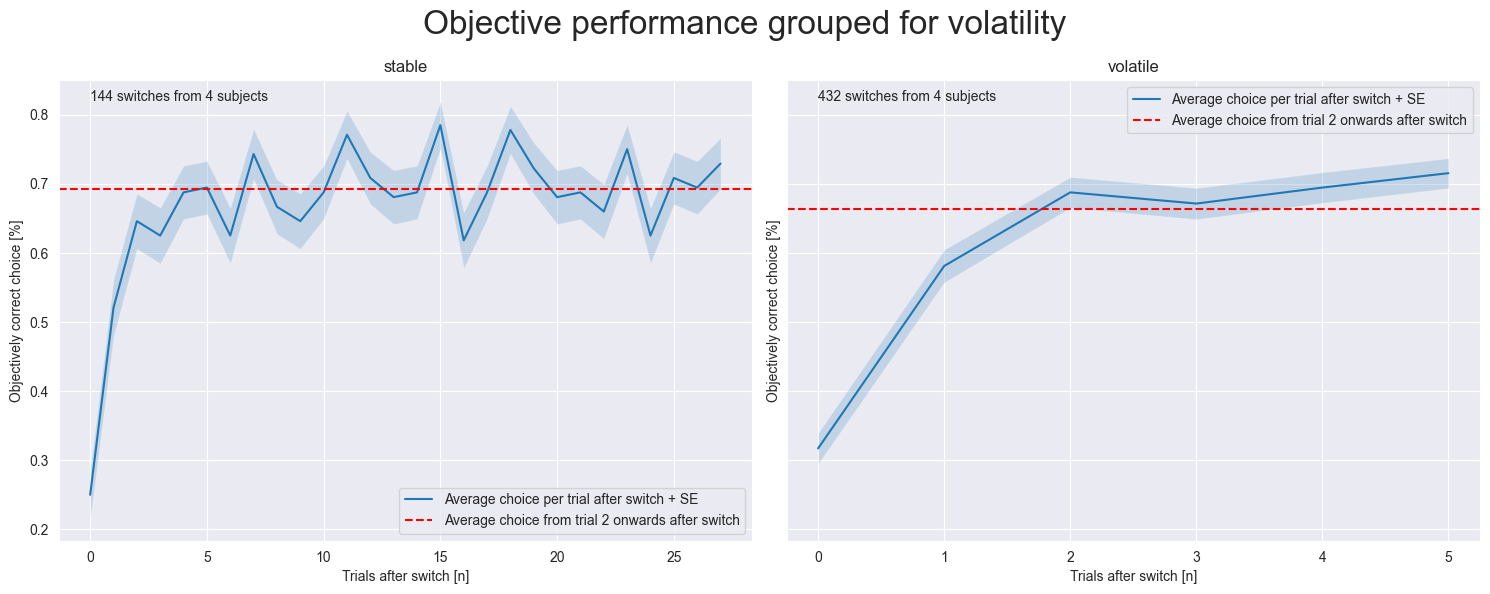

In [41]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_switch_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_switch_total[i], color='r', linestyle='--', label='Average choice from trial 2 onwards after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} switches from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [42]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a switch
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe)

/Volumes/affneu/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:300: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''


[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2315, 2325, 2331, 2339, 2349, 238

# Still needs fix where only transitions of volatile to volatile and stable to stable are used

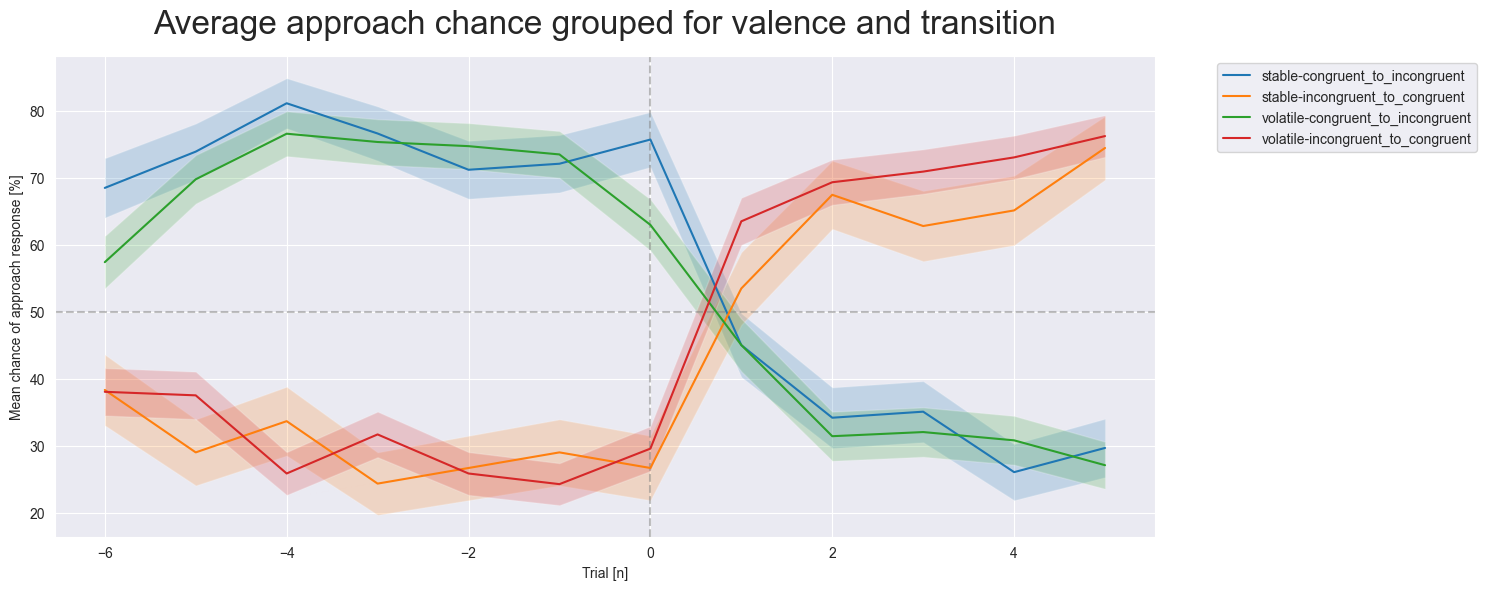

In [43]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

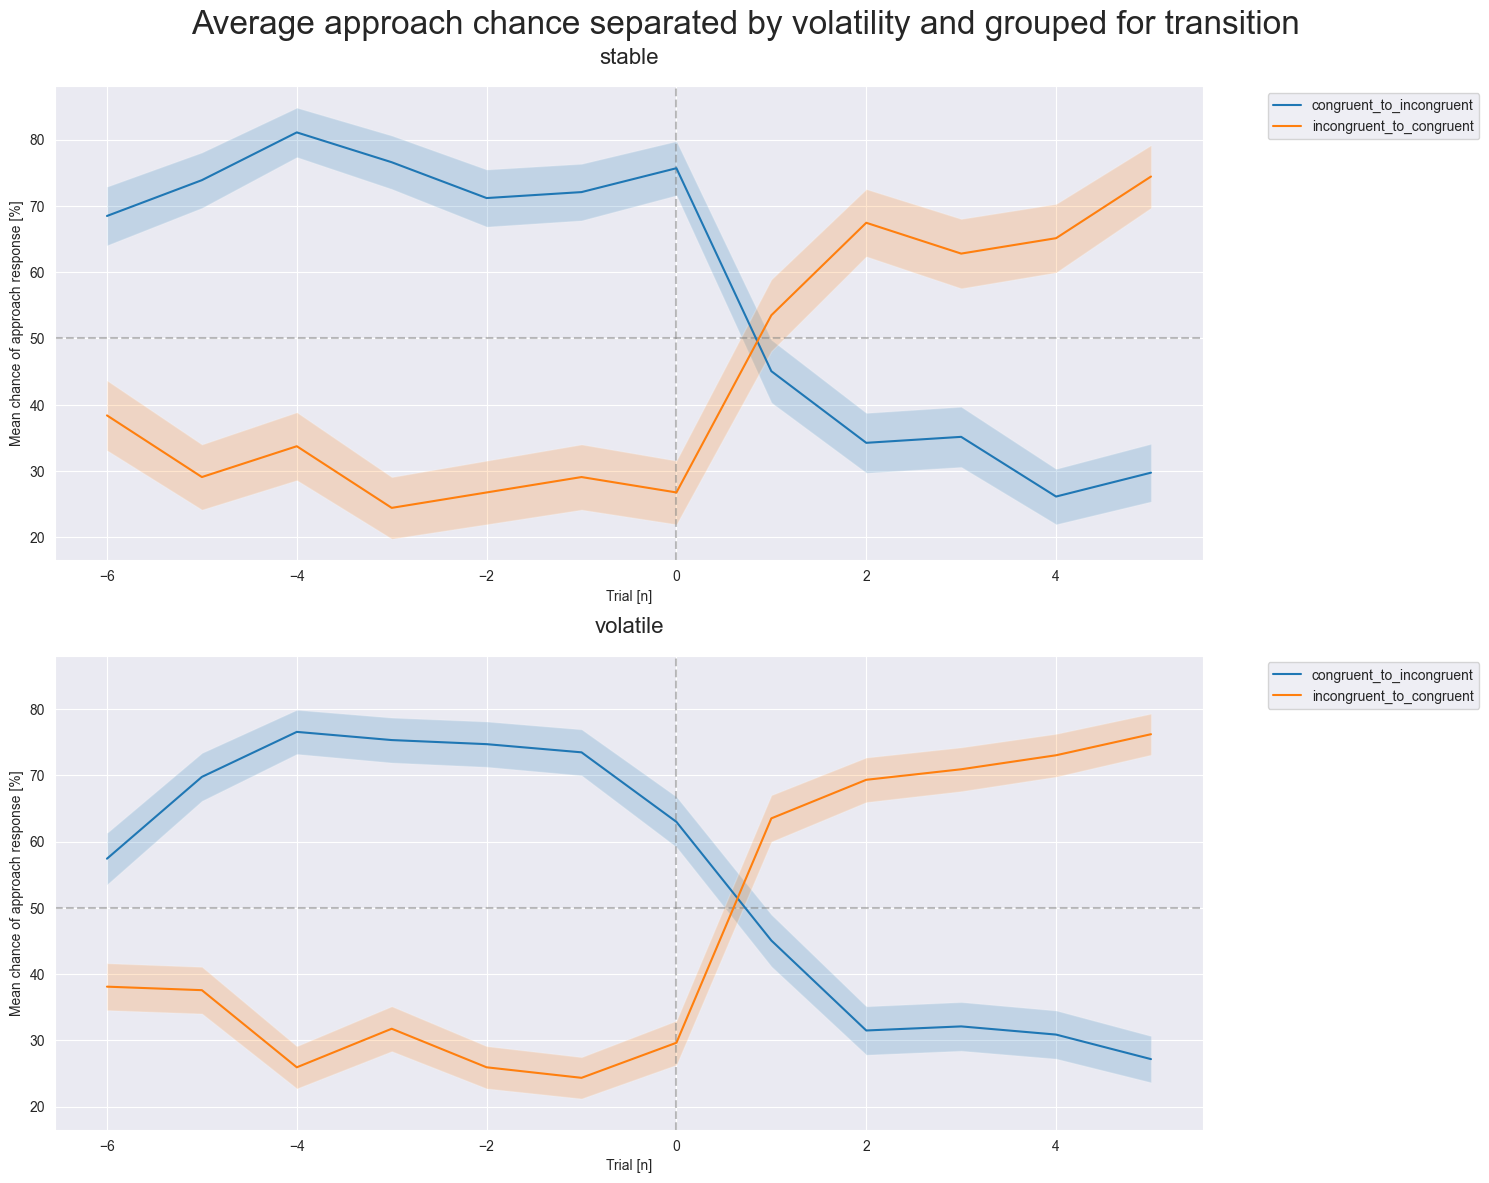

In [44]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance separated by volatility and grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()